# 선문대학교 컴퓨터공학부
# 2022243101 최완우

## 선형회귀 실습
### 캘리포니아의 집 가격을 비교하여 예측하는 학습

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. 데이터 불러오기
housing = fetch_california_housing()
print(housing.DESCR) # 데이터에 대한 설명 출력

# 데이터 프레임 만들기 (독립변수 X)
X = pd.DataFrame(housing.data, columns=housing.feature_names)

# 종속변수 Series 만들기 (y)
y = pd.Series(housing.target, name="MedHouseValue")


.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [9]:
# 전체 데이터를 한눈에 보기 위해 X와 y를 합친 data 생성
data = pd.concat([X, y])
# 인덱스 개수 확인
data

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseValue
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,NaN
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,NaN
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,NaN
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,NaN
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,NaN
...,...,...,...,...,...,...,...,...,...
20635,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.781
20636,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.771
20637,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.923
20638,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.847


In [ ]:
# 상위 5줄 출력
data.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseValue
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,NaN
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,NaN
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,NaN
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,NaN
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,NaN


In [ ]:
# 컬럼 정보 출력
data.info()

<class 'pandas.DataFrame'>
Index: 41280 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MedInc         20640 non-null  float64
 1   HouseAge       20640 non-null  float64
 2   AveRooms       20640 non-null  float64
 3   AveBedrms      20640 non-null  float64
 4   Population     20640 non-null  float64
 5   AveOccup       20640 non-null  float64
 6   Latitude       20640 non-null  float64
 7   Longitude      20640 non-null  float64
 8   MedHouseValue  20640 non-null  float64
dtypes: float64(9)
memory usage: 3.1 MB


In [ ]:
# 통계 정보 출력
data.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseValue
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [13]:
# 소수점 2째자리까지만 표시해 통계 정보 출력
round(data.describe(), 2)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseValue
count,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00
mean,3.87,28.64,5.43,1.10,1425.48,3.07,35.63,-119.57,2.07
std,1.90,12.59,2.47,0.47,1132.46,10.39,2.14,2.00,1.15
min,0.50,1.00,0.85,0.33,3.00,0.69,32.54,-124.35,0.15
25%,2.56,18.00,4.44,1.01,787.00,2.43,33.93,-121.80,1.20
50%,3.53,29.00,5.23,1.05,1166.00,2.82,34.26,-118.49,1.80
75%,4.74,37.00,6.05,1.10,1725.00,3.28,37.71,-118.01,2.65
max,15.00,52.00,141.91,34.07,35682.00,1243.33,41.95,-114.31,5.00


In [ ]:
# 데이터셋 분할(테스트 30% / 학습 70%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 100)

In [18]:
model = LinearRegression()
model.fit(X_train, y_train)
pred = model.predict(X_test)        # X_test : 예측 대상

In [ ]:
# 테이블로 평가하기
comparison = pd.DataFrame({'actual' : y_test, 'pred' : pred})
comparison

,actual,pred
8151,2.453,2.086920
53,1.042,1.588411
3039,1.462,2.092174
9484,1.542,1.591352
9307,3.242,2.049706
...,...,...
11584,2.376,2.901033
2767,0.543,0.888247
9481,0.840,1.408364
2258,0.656,1.494365


<Axes: xlabel='actual', ylabel='pred'>

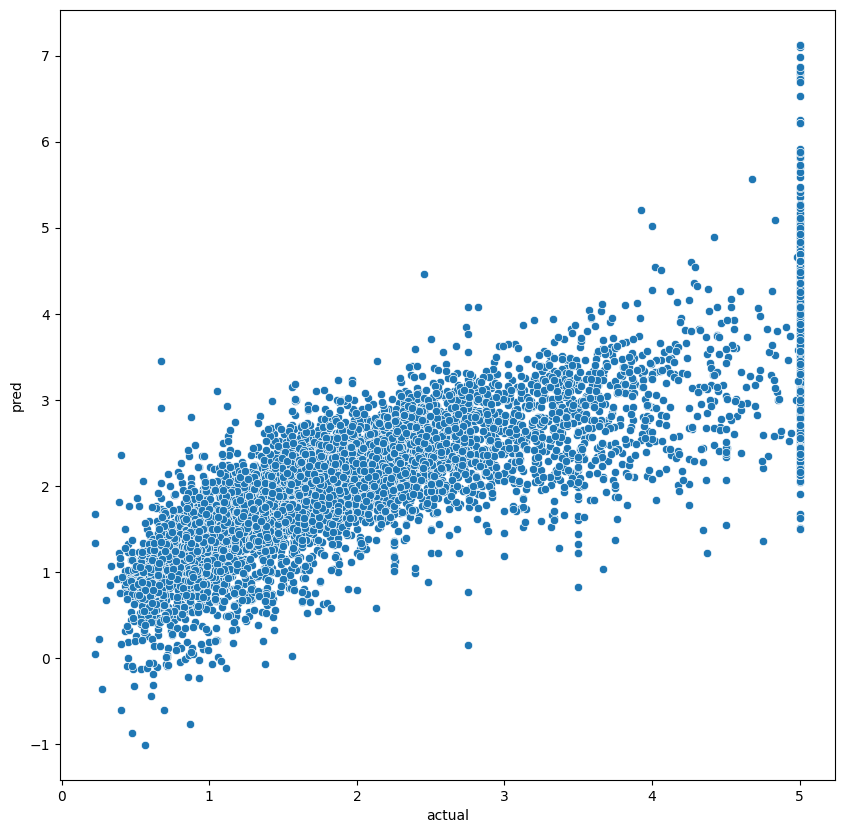

In [24]:
# 그래프로 평가하기
plt.figure(figsize=(10, 10))
sns.scatterplot(x = 'actual', y = 'pred', data = comparison)

In [10]:
mse = mean_squared_error(y_test, pred)
rmse = mse ** 0.5
mae = mean_absolute_error(y_test, pred)
r2 = r2_score(y_test, pred)

print(f"RMSE (루트 평균 제곱 오차) : {rmse:.4f}")
print(f"MAE (평균 절대 오차) : {mae:.4f}")
print(f"R2 Score (결정 계수) : {r2:.4f}")

RMSE (루트 평균 제곱 오차) : 0.7134
MAE (평균 절대 오차) : 0.5278
R2 Score (결정 계수) : 0.6223


In [11]:
coef_series = pd.Series(model.coef_, index = X.columns)
print("=== 각 독립변수의 기울기(계수) ===")
print(coef_series)

print('\n=== y절편 ===')
print(model.intercept_)

=== 각 독립변수의 기울기(계수) ===
MedInc        0.433433
HouseAge      0.009226
AveRooms     -0.106548
AveBedrms     0.646494
Population   -0.000007
AveOccup     -0.003459
Latitude     -0.423282
Longitude    -0.437466
dtype: float64

=== y절편 ===
-37.20562128878817
